<a href="https://colab.research.google.com/github/jensjose07/deep_learning_lab/blob/main/experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [81]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow Version: 2.20.0
GPU Available: True


In [82]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

In [83]:
x_test_raw = x_test.copy()
y_test_raw = y_test.flatten()

In [84]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [85]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [86]:
def create_model(hidden_units, activation):
    """
    Builds a 3-hidden-layer Feed Forward Neural Network.
    """
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(hidden_units[0], activation=activation),
        Dense(hidden_units[1], activation=activation),
        Dense(hidden_units[2], activation=activation),
        Dense(10, activation='softmax')
    ])
    return model

In [87]:
hidden_units_list = [
    (1024, 512, 256),
    (256, 128, 64)
]

activation_list = ['relu', 'tanh', 'sigmoid']

best_acc = 0.0
best_model = None
best_config = None

print("\n" + "="*55)
print(" STARTING HYPERPARAMETER GRID SEARCH")
print("="*55)

for units in hidden_units_list:
    for act in activation_list:
        print(f"\n▶ Testing Config: Hidden Units = {units} | Activation = '{act}'")


 STARTING HYPERPARAMETER GRID SEARCH

▶ Testing Config: Hidden Units = (1024, 512, 256) | Activation = 'relu'

▶ Testing Config: Hidden Units = (1024, 512, 256) | Activation = 'tanh'

▶ Testing Config: Hidden Units = (1024, 512, 256) | Activation = 'sigmoid'

▶ Testing Config: Hidden Units = (256, 128, 64) | Activation = 'relu'

▶ Testing Config: Hidden Units = (256, 128, 64) | Activation = 'tanh'

▶ Testing Config: Hidden Units = (256, 128, 64) | Activation = 'sigmoid'


In [88]:
model = create_model(units, act)

In [89]:
model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

In [90]:
model.fit(
            x_train, y_train,
            epochs=5,
            batch_size=64,
            verbose=1
        )

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2618 - loss: 1.9943
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3479 - loss: 1.8017
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3753 - loss: 1.7289
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3877 - loss: 1.6903
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4019 - loss: 1.6539


In [91]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"--> Test Accuracy: {test_acc * 100:.2f}%")

--> Test Accuracy: 39.10%


In [92]:
if test_acc > best_acc:
            best_acc = test_acc
            best_model = model
            best_config = (units, act)

In [93]:
print("\n" + "=" * 55)
print(" OPTIMAL MODEL FOUND")
print("=" * 55)
print(f"Best Hidden Architecture : {best_config[0]}")
print(f"Best Activation Function : '{best_config[1]}'")
print(f"Highest Test Accuracy   : {best_acc * 100:.2f}%")
print("=" * 55)


 OPTIMAL MODEL FOUND
Best Hidden Architecture : (256, 128, 64)
Best Activation Function : 'sigmoid'
Highest Test Accuracy   : 39.10%


In [94]:
sample_idx = 0  # Index of test image to predict
sample_img = x_test[sample_idx]
sample_img_input = np.expand_dims(sample_img, axis=0)

In [95]:
prediction_probs = best_model.predict(sample_img_input)
predicted_class_idx = np.argmax(prediction_probs)
actual_class_idx = y_test_raw[sample_idx]

predicted_label = class_names[predicted_class_idx]
actual_label = class_names[actual_class_idx]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step


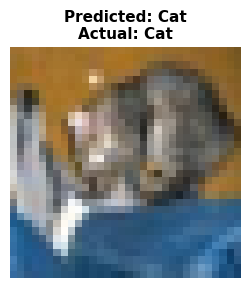

In [96]:
plt.figure(figsize=(3, 3))
plt.imshow(x_test_raw[sample_idx])
plt.axis('off')
plt.title(f"Predicted: {predicted_label}\nActual: {actual_label}", fontsize=11, fontweight='bold')
plt.show()